# Full Pipeline: Silent Struggle Prediction

Notebook ini berisi pipeline lengkap dari:

1. load dataset,
2. cleaning data,
3. pembuatan label `support_status` dan `priority_segment`,
4. exploratory check singkat,
5. preprocessing fitur,
6. training model machine learning,
7. evaluasi model,
8. prediksi label,
9. export hasil prediksi.

> Catatan penting: Label `support_status` dan `priority_segment` dibuat dari indikator `depression`, `anxiety`, `panic_attack`, dan `seek_specialist`.  
> Untuk menghindari **data leakage**, model prediksi pada notebook ini **tidak menggunakan kolom pembentuk label** sebagai fitur prediksi.  
> Model hanya menggunakan fitur profil/demografis/akademik seperti gender, age, course, year study, CGPA, dan marital status.

Notebook ini bukan alat diagnosis medis, melainkan prototype analitik untuk kebutuhan Smart Campus.

## 1. Import Library dan Setup

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Folder kerja
base_dir = Path("/mnt/data") if Path("/mnt/data").exists() else Path.cwd()
output_dir = base_dir / "prediction_pipeline_outputs"
table_dir = output_dir / "tables"
viz_dir = output_dir / "visualizations"
model_output_dir = output_dir / "predictions"

for folder in [table_dir, viz_dir, model_output_dir]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titleweight": "bold",
    "font.size": 10
})

## 2. Load Dataset

Dataset dapat berasal dari:

- `student_mental_health_with_labels.csv`, jika sudah ada dataset berlabel; atau
- `Student Mental health.csv`, lalu label dibuat ulang di notebook.

In [2]:
labeled_path = base_dir / "label_outputs" / "student_mental_health_with_labels.csv"
raw_path = base_dir / "Student Mental health.csv"

if labeled_path.exists():
    df_raw = pd.read_csv(labeled_path)
    source_used = labeled_path
else:
    df_raw = pd.read_csv(raw_path)
    source_used = raw_path

print("Dataset yang digunakan:", source_used)
print("Jumlah baris:", df_raw.shape[0])
print("Jumlah kolom:", df_raw.shape[1])
display(df_raw.head())

Dataset yang digunakan: c:\Users\MSI SWORD 16\Kuliah\Lomba\TEKRA\label_outputs\student_mental_health_with_labels.csv
Jumlah baris: 101
Jumlah kolom: 19


,student_id,timestamp,gender,age,course,course_clean,year_study,cgpa,marital_status,depression,anxiety,panic_attack,seek_specialist,issue_count,has_any_issue,multiple_issue,indicator_combination,support_status,priority_segment
0,S001,8/7/2020 12:02,Female,18.0,Engineering,Engineering,Year 1,3.00 - 3.49,0,1,0,1,0,2,True,True,Depression + Panic Attack,Silent Struggle,High Concern
1,S002,8/7/2020 12:04,Male,21.0,Islamic education,Islamic Education,Year 2,3.00 - 3.49,0,0,1,0,0,1,True,False,Anxiety,Silent Struggle,Low Concern
2,S003,8/7/2020 12:05,Male,19.0,BIT,BIT,Year 1,3.00 - 3.49,0,1,1,1,0,3,True,True,Depression + Anxiety + Panic Attack,Silent Struggle,High Concern
3,S004,8/7/2020 12:06,Female,22.0,Laws,Laws,Year 3,3.00 - 3.49,1,1,0,0,0,1,True,False,Depression,Silent Struggle,Low Concern
4,S005,8/7/2020 12:13,Male,23.0,Mathemathics,Mathemathics,Year 4,3.00 - 3.49,0,0,0,0,0,0,False,False,No Indicator,Stable / No Reported Indicator,Stable


## 3. Cleaning dan Standardisasi Data

Jika dataset yang masuk belum memiliki label, notebook akan membuat label dari awal. Jika sudah memiliki label, notebook tetap memastikan format kolomnya konsisten.

In [3]:
df = df_raw.copy()

# Jika dataset masih versi mentah, rename kolomnya
rename_map = {
    "Timestamp": "timestamp",
    "Choose your gender": "gender",
    "Age": "age",
    "What is your course?": "course",
    "Your current year of Study": "year_study",
    "What is your CGPA?": "cgpa",
    "Marital status": "marital_status",
    "Do you have Depression?": "depression",
    "Do you have Anxiety?": "anxiety",
    "Do you have Panic attack?": "panic_attack",
    "Did you seek any specialist for a treatment?": "seek_specialist"
}
df = df.rename(columns=rename_map)

# Bersihkan spasi pada kolom object
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Tambahkan student_id jika belum ada
if "student_id" not in df.columns:
    df.insert(0, "student_id", [f"S{i:03d}" for i in range(1, len(df) + 1)])

# Age
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["age"] = df["age"].fillna(df["age"].median())

# Year study
df["year_study"] = (
    df["year_study"]
    .astype(str)
    .str.lower()
    .str.replace("year", "Year", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# CGPA
df["cgpa"] = (
    df["cgpa"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Course
if "course_clean" not in df.columns:
    df["course_clean"] = (
        df["course"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.title()
    )
else:
    df["course_clean"] = (
        df["course_clean"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.title()
    )

course_map = {
    "Benl": "BENL",
    "Bcs": "BCS",
    "Bit": "BIT",
    "Irkhs": "IRKHS",
    "Koe": "KOE",
    "Econs": "Economics",
    "Engine": "Engineering",
    "Fiqh Fatwa": "Fiqh",
    "Kirkhs": "KIRKHS",
}
df["course_clean"] = df["course_clean"].replace(course_map)

# Pastikan kolom Yes/No menjadi 1/0.
# Jika sudah 1/0, biarkan.
yes_no_cols = ["depression", "anxiety", "panic_attack", "seek_specialist", "marital_status"]

for col in yes_no_cols:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.title().map({"Yes": 1, "No": 0, "1": 1, "0": 0})
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

display(df.head())

,student_id,timestamp,gender,age,course,course_clean,year_study,cgpa,marital_status,depression,anxiety,panic_attack,seek_specialist,issue_count,has_any_issue,multiple_issue,indicator_combination,support_status,priority_segment
0,S001,8/7/2020 12:02,Female,18.0,Engineering,Engineering,Year 1,3.00 - 3.49,0,1,0,1,0,2,True,True,Depression + Panic Attack,Silent Struggle,High Concern
1,S002,8/7/2020 12:04,Male,21.0,Islamic education,Islamic Education,Year 2,3.00 - 3.49,0,0,1,0,0,1,True,False,Anxiety,Silent Struggle,Low Concern
2,S003,8/7/2020 12:05,Male,19.0,BIT,BIT,Year 1,3.00 - 3.49,0,1,1,1,0,3,True,True,Depression + Anxiety + Panic Attack,Silent Struggle,High Concern
3,S004,8/7/2020 12:06,Female,22.0,Laws,Laws,Year 3,3.00 - 3.49,1,1,0,0,0,1,True,False,Depression,Silent Struggle,Low Concern
4,S005,8/7/2020 12:13,Male,23.0,Mathemathics,Mathemathics,Year 4,3.00 - 3.49,0,0,0,0,0,0,False,False,No Indicator,Stable / No Reported Indicator,Stable


## 4. Membuat atau Memastikan Label

Label yang digunakan:

- `support_status`
- `priority_segment`

Label dibuat dari jumlah indikasi mental health dan status pencarian bantuan profesional.

In [4]:
issue_cols = ["depression", "anxiety", "panic_attack"]

df["issue_count"] = df[issue_cols].sum(axis=1)
df["has_any_issue"] = df["issue_count"] > 0
df["multiple_issue"] = df["issue_count"] >= 2

def make_support_status(row):
    if row["issue_count"] == 0:
        return "Stable / No Reported Indicator"
    elif row["seek_specialist"] == 1:
        return "Reached Support"
    else:
        return "Silent Struggle"

def make_priority_segment(row):
    if row["issue_count"] == 0:
        return "Stable"
    elif row["seek_specialist"] == 1:
        return "Supported"
    elif row["issue_count"] == 1:
        return "Low Concern"
    else:
        return "High Concern"

def make_indicator_combination(row):
    indicators = []
    if row["depression"] == 1:
        indicators.append("Depression")
    if row["anxiety"] == 1:
        indicators.append("Anxiety")
    if row["panic_attack"] == 1:
        indicators.append("Panic Attack")
    return " + ".join(indicators) if indicators else "No Indicator"

df["support_status"] = df.apply(make_support_status, axis=1)
df["priority_segment"] = df.apply(make_priority_segment, axis=1)
df["indicator_combination"] = df.apply(make_indicator_combination, axis=1)

display(df[[
    "student_id", "gender", "age", "course_clean", "year_study", "cgpa",
    "depression", "anxiety", "panic_attack", "seek_specialist",
    "issue_count", "support_status", "priority_segment"
]].head(15))

,student_id,gender,age,course_clean,year_study,cgpa,depression,anxiety,panic_attack,seek_specialist,issue_count,support_status,priority_segment
0,S001,Female,18.0,Engineering,Year 1,3.00 - 3.49,1,0,1,0,2,Silent Struggle,High Concern
1,S002,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,0,1,0,0,1,Silent Struggle,Low Concern
2,S003,Male,19.0,BIT,Year 1,3.00 - 3.49,1,1,1,0,3,Silent Struggle,High Concern
3,S004,Female,22.0,Laws,Year 3,3.00 - 3.49,1,0,0,0,1,Silent Struggle,Low Concern
4,S005,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,0,0,0,0,0,Stable / No Reported Indicator,Stable
5,S006,Male,19.0,Engineering,Year 2,3.50 - 4.00,0,0,1,0,1,Silent Struggle,Low Concern
6,S007,Female,23.0,Pendidikan Islam,Year 2,3.50 - 4.00,1,0,1,0,2,Silent Struggle,High Concern
7,S008,Female,18.0,BCS,Year 1,3.50 - 4.00,0,1,0,0,1,Silent Struggle,Low Concern
8,S009,Female,19.0,Human Resources,Year 2,2.50 - 2.99,0,0,0,0,0,Stable / No Reported Indicator,Stable
9,S010,Male,18.0,IRKHS,Year 1,3.50 - 4.00,0,1,1,0,2,Silent Struggle,High Concern


## 5. Ringkasan Distribusi Label

Sebelum modeling, lihat distribusi kelas. Ini penting karena dataset kecil dan beberapa kelas memiliki jumlah data yang sedikit.

In [5]:
support_summary = (
    df["support_status"]
    .value_counts()
    .rename_axis("support_status")
    .reset_index(name="count")
)
support_summary["percentage"] = (support_summary["count"] / len(df) * 100).round(2)

priority_order = ["Stable", "Low Concern", "High Concern", "Supported"]
priority_summary = (
    df["priority_segment"]
    .value_counts()
    .reindex(priority_order)
    .fillna(0)
    .astype(int)
    .rename_axis("priority_segment")
    .reset_index(name="count")
)
priority_summary["percentage"] = (priority_summary["count"] / len(df) * 100).round(2)

display(Markdown("### Distribusi support_status"))
display(support_summary)

display(Markdown("### Distribusi priority_segment"))
display(priority_summary)

support_summary.to_csv(table_dir / "support_status_distribution.csv", index=False)
priority_summary.to_csv(table_dir / "priority_segment_distribution.csv", index=False)

### Distribusi support_status

,support_status,count,percentage
0,Silent Struggle,58,57.43
1,Stable / No Reported Indicator,37,36.63
2,Reached Support,6,5.94


### Distribusi priority_segment

,priority_segment,count,percentage
0,Stable,37,36.63
1,Low Concern,36,35.64
2,High Concern,22,21.78
3,Supported,6,5.94


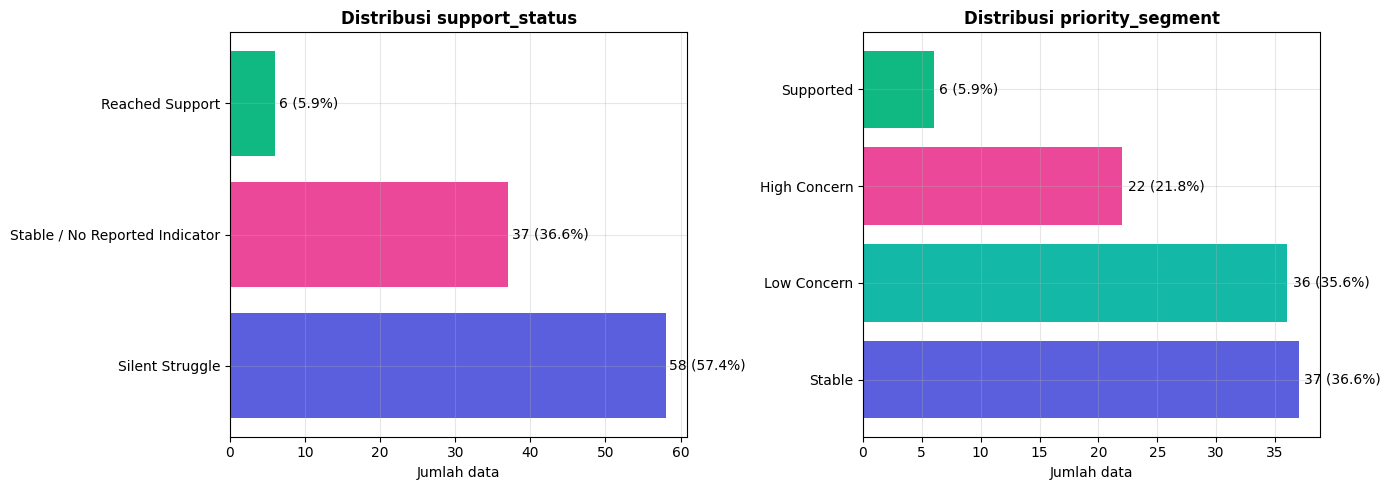

In [6]:
# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

support_colors = ["#5B5FDE", "#EC4899", "#10B981"]
priority_colors = ["#5B5FDE", "#14B8A6", "#EC4899", "#10B981"]

axes[0].barh(support_summary["support_status"], support_summary["count"], color=support_colors)
axes[0].set_title("Distribusi support_status")
axes[0].set_xlabel("Jumlah data")

for i, row in support_summary.iterrows():
    axes[0].text(row["count"] + 0.5, i, f'{row["count"]} ({row["percentage"]:.1f}%)', va="center")

axes[1].barh(priority_summary["priority_segment"], priority_summary["count"], color=priority_colors)
axes[1].set_title("Distribusi priority_segment")
axes[1].set_xlabel("Jumlah data")

for i, row in priority_summary.iterrows():
    axes[1].text(row["count"] + 0.5, i, f'{row["count"]} ({row["percentage"]:.1f}%)', va="center")

plt.tight_layout()
plt.savefig(viz_dir / "01_label_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

## 6. Feature Selection untuk Prediction

Agar tidak terjadi **data leakage**, fitur pembentuk label tidak digunakan sebagai input model.

Kolom yang **tidak digunakan sebagai fitur**:

- `depression`
- `anxiety`
- `panic_attack`
- `seek_specialist`
- `issue_count`
- `has_any_issue`
- `multiple_issue`
- `indicator_combination`
- `support_status`
- `priority_segment`

Fitur yang digunakan model:

- `gender`
- `age`
- `course_clean`
- `year_study`
- `cgpa`
- `marital_status`

In [7]:
feature_cols = [
    "gender",
    "age",
    "course_clean",
    "year_study",
    "cgpa",
    "marital_status"
]

X = df[feature_cols].copy()

y_support = df["support_status"].copy()
y_priority = df["priority_segment"].copy()

numeric_features = ["age"]
categorical_features = ["gender", "course_clean", "year_study", "cgpa", "marital_status"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

display(X.head())

,gender,age,course_clean,year_study,cgpa,marital_status
0,Female,18.0,Engineering,Year 1,3.00 - 3.49,0
1,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,0
2,Male,19.0,BIT,Year 1,3.00 - 3.49,0
3,Female,22.0,Laws,Year 3,3.00 - 3.49,1
4,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,0


## 7. Modeling Function

Bagian ini membuat fungsi agar proses training dan evaluasi bisa dilakukan untuk dua target:

1. `support_status`
2. `priority_segment`

In [8]:
def evaluate_models(X, y, target_name, test_size=0.25):
    print(f"\n==============================")
    print(f"TARGET: {target_name}")
    print(f"==============================")

    # Split stratified agar distribusi kelas tetap proporsional
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y
    )

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        "Decision Tree": DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    }

    results = []
    trained_models = {}

    for model_name, model in models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        # Cross-validation ringan. Jumlah fold dibatasi agar aman untuk kelas kecil.
        min_class_count = y.value_counts().min()
        n_splits = max(2, min(3, min_class_count))
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1_weighted")

        results.append({
            "target": target_name,
            "model": model_name,
            "accuracy": round(acc, 4),
            "macro_f1": round(macro_f1, 4),
            "weighted_f1": round(weighted_f1, 4),
            "cv_weighted_f1_mean": round(cv_scores.mean(), 4),
            "cv_weighted_f1_std": round(cv_scores.std(), 4)
        })

        trained_models[model_name] = pipe

        print(f"\n--- {model_name} ---")
        print("Accuracy   :", round(acc, 4))
        print("Macro F1   :", round(macro_f1, 4))
        print("Weighted F1:", round(weighted_f1, 4))
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))

    results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
    best_model_name = results_df.iloc[0]["model"]
    best_model = trained_models[best_model_name]

    print("\nModel terbaik berdasarkan weighted F1:", best_model_name)
    display(results_df)

    # Confusion matrix model terbaik
    y_pred_best = best_model.predict(X_test)
    labels = sorted(y.unique())
    cm = confusion_matrix(y_test, y_pred_best, labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Purples", colorbar=False)
    ax.set_title(f"Confusion Matrix - {target_name} - {best_model_name}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(viz_dir / f"confusion_matrix_{target_name}.png", dpi=220, bbox_inches="tight")
    plt.show()

    return {
        "target": target_name,
        "results": results_df,
        "best_model_name": best_model_name,
        "best_model": best_model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred_test": y_pred_best
    }

## 8. Train dan Evaluasi Model untuk `support_status`


TARGET: support_status

--- Logistic Regression ---
Accuracy   : 0.4615
Macro F1   : 0.5211
Weighted F1: 0.4724

Classification Report:
                                precision    recall  f1-score   support

               Reached Support       1.00      0.50      0.67         2
               Silent Struggle       0.60      0.40      0.48        15
Stable / No Reported Indicator       0.33      0.56      0.42         9

                      accuracy                           0.46        26
                     macro avg       0.64      0.49      0.52        26
                  weighted avg       0.54      0.46      0.47        26


--- Decision Tree ---
Accuracy   : 0.6538
Macro F1   : 0.5856
Weighted F1: 0.6033

Classification Report:
                                precision    recall  f1-score   support

               Reached Support       1.00      0.50      0.67         2
               Silent Struggle       0.64      0.93      0.76        15
Stable / No Reported Indicator  

,target,model,accuracy,macro_f1,weighted_f1,cv_weighted_f1_mean,cv_weighted_f1_std
0,support_status,Decision Tree,0.6538,0.5856,0.6033,0.4901,0.0836
1,support_status,Logistic Regression,0.4615,0.5211,0.4724,0.5103,0.0376
2,support_status,Random Forest,0.4231,0.2927,0.4105,0.4795,0.0622


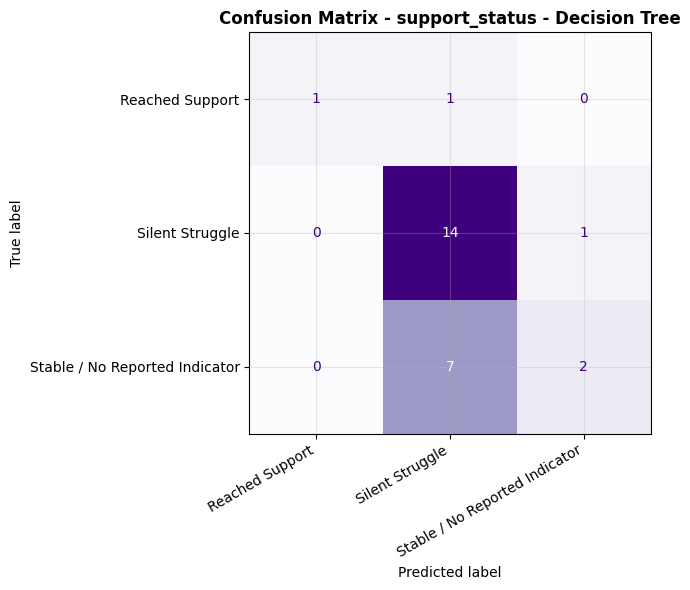

In [9]:
support_eval = evaluate_models(X, y_support, "support_status")
support_eval["results"].to_csv(table_dir / "model_comparison_support_status.csv", index=False)

## 9. Train dan Evaluasi Model untuk `priority_segment`


TARGET: priority_segment

--- Logistic Regression ---
Accuracy   : 0.3077
Macro F1   : 0.3297
Weighted F1: 0.336

Classification Report:
              precision    recall  f1-score   support

High Concern       0.08      0.17      0.11         6
 Low Concern       0.50      0.22      0.31         9
      Stable       0.57      0.44      0.50         9
   Supported       0.33      0.50      0.40         2

    accuracy                           0.31        26
   macro avg       0.37      0.33      0.33        26
weighted avg       0.42      0.31      0.34        26


--- Decision Tree ---
Accuracy   : 0.2308
Macro F1   : 0.2597
Weighted F1: 0.2114

Classification Report:
              precision    recall  f1-score   support

High Concern       0.09      0.17      0.12         6
 Low Concern       0.00      0.00      0.00         9
      Stable       0.40      0.44      0.42         9
   Supported       0.50      0.50      0.50         2

    accuracy                           0.23     

,target,model,accuracy,macro_f1,weighted_f1,cv_weighted_f1_mean,cv_weighted_f1_std
0,priority_segment,Logistic Regression,0.3077,0.3297,0.3360,0.3135,0.0726
1,priority_segment,Random Forest,0.2692,0.2083,0.2596,0.2920,0.0947
2,priority_segment,Decision Tree,0.2308,0.2597,0.2114,0.1624,0.0640


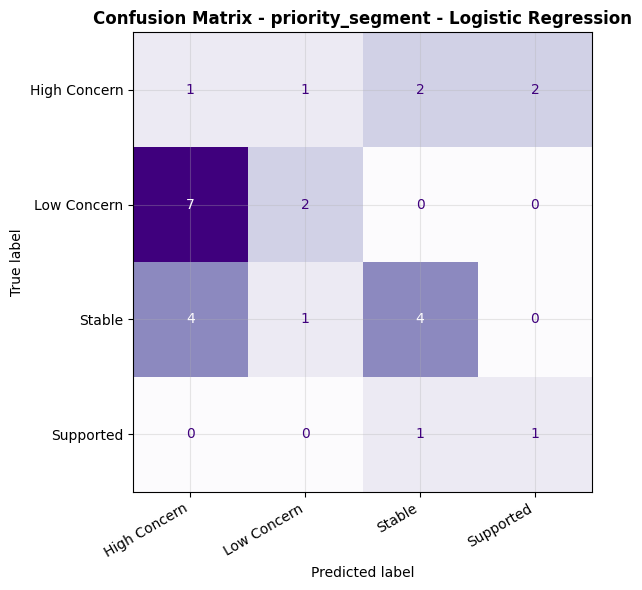

In [10]:
priority_eval = evaluate_models(X, y_priority, "priority_segment")
priority_eval["results"].to_csv(table_dir / "model_comparison_priority_segment.csv", index=False)

## 10. Perbandingan Model Final

Bagian ini menggabungkan hasil evaluasi dari dua target.

,target,model,accuracy,macro_f1,weighted_f1,cv_weighted_f1_mean,cv_weighted_f1_std
0,support_status,Decision Tree,0.6538,0.5856,0.6033,0.4901,0.0836
1,support_status,Logistic Regression,0.4615,0.5211,0.4724,0.5103,0.0376
2,support_status,Random Forest,0.4231,0.2927,0.4105,0.4795,0.0622
3,priority_segment,Logistic Regression,0.3077,0.3297,0.3360,0.3135,0.0726
4,priority_segment,Random Forest,0.2692,0.2083,0.2596,0.2920,0.0947
5,priority_segment,Decision Tree,0.2308,0.2597,0.2114,0.1624,0.0640


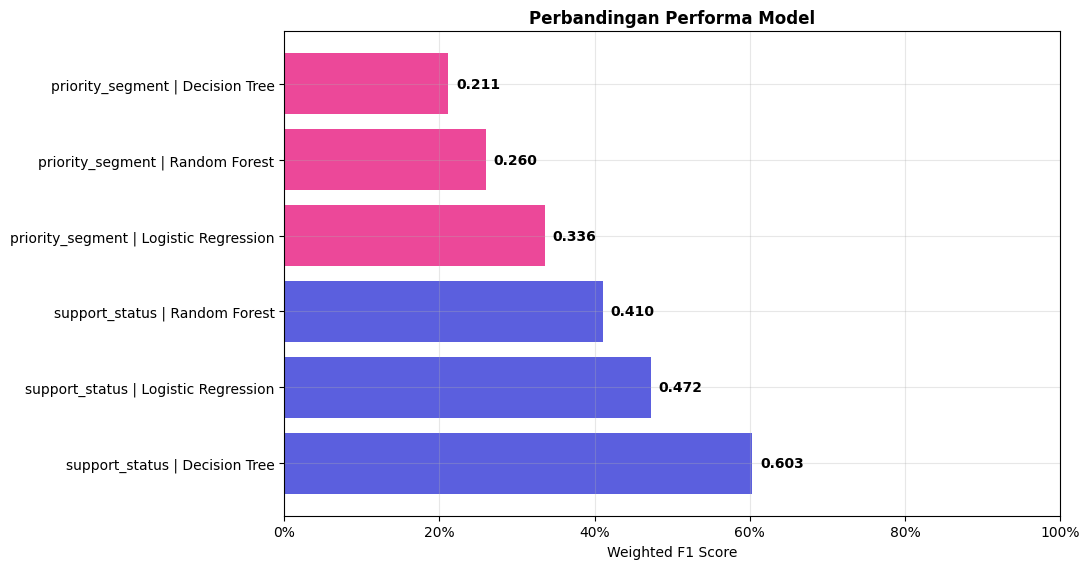

In [11]:
model_comparison = pd.concat([
    support_eval["results"],
    priority_eval["results"]
], ignore_index=True)

display(model_comparison)

model_comparison.to_csv(table_dir / "model_comparison_all_targets.csv", index=False)

# Visualisasi perbandingan Weighted F1
fig, ax = plt.subplots(figsize=(11, 5.8))

plot_df = model_comparison.copy()
plot_df["label"] = plot_df["target"] + " | " + plot_df["model"]

colors = ["#5B5FDE" if target == "support_status" else "#EC4899" for target in plot_df["target"]]

ax.barh(plot_df["label"], plot_df["weighted_f1"], color=colors)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Weighted F1 Score")
ax.set_title("Perbandingan Performa Model")

for i, row in plot_df.iterrows():
    ax.text(row["weighted_f1"] + 0.01, i, f'{row["weighted_f1"]:.3f}', va="center", fontweight="bold")

plt.tight_layout()
plt.savefig(viz_dir / "02_model_comparison_weighted_f1.png", dpi=220, bbox_inches="tight")
plt.show()

## 11. Training Model Final pada Seluruh Dataset

Setelah evaluasi, model terbaik dari masing-masing target dilatih ulang menggunakan seluruh data agar bisa menghasilkan prediksi untuk semua responden.

In [12]:
best_support_model = support_eval["best_model"]
best_priority_model = priority_eval["best_model"]

# Refit ke seluruh dataset
best_support_model.fit(X, y_support)
best_priority_model.fit(X, y_priority)

df_pred = df.copy()

df_pred["predicted_support_status"] = best_support_model.predict(X)
df_pred["predicted_priority_segment"] = best_priority_model.predict(X)

# Tambahkan probabilitas prediksi jika model mendukung predict_proba
if hasattr(best_support_model, "predict_proba"):
    support_proba = best_support_model.predict_proba(X)
    support_classes = best_support_model.classes_
    for i, cls in enumerate(support_classes):
        df_pred[f"proba_support_{cls}"] = support_proba[:, i].round(4)

if hasattr(best_priority_model, "predict_proba"):
    priority_proba = best_priority_model.predict_proba(X)
    priority_classes = best_priority_model.classes_
    for i, cls in enumerate(priority_classes):
        df_pred[f"proba_priority_{cls}"] = priority_proba[:, i].round(4)

display(df_pred[[
    "student_id",
    "gender",
    "age",
    "course_clean",
    "year_study",
    "cgpa",
    "support_status",
    "predicted_support_status",
    "priority_segment",
    "predicted_priority_segment"
]].head(20))

,student_id,gender,age,course_clean,year_study,cgpa,support_status,predicted_support_status,priority_segment,predicted_priority_segment
0,S001,Female,18.0,Engineering,Year 1,3.00 - 3.49,Silent Struggle,Stable / No Reported Indicator,High Concern,High Concern
1,S002,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,Silent Struggle,Stable / No Reported Indicator,Low Concern,Low Concern
2,S003,Male,19.0,BIT,Year 1,3.00 - 3.49,Silent Struggle,Silent Struggle,High Concern,High Concern
3,S004,Female,22.0,Laws,Year 3,3.00 - 3.49,Silent Struggle,Silent Struggle,Low Concern,Low Concern
4,S005,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,Stable / No Reported Indicator,Stable / No Reported Indicator,Stable,Stable
5,S006,Male,19.0,Engineering,Year 2,3.50 - 4.00,Silent Struggle,Stable / No Reported Indicator,Low Concern,Low Concern
6,S007,Female,23.0,Pendidikan Islam,Year 2,3.50 - 4.00,Silent Struggle,Reached Support,High Concern,Supported
7,S008,Female,18.0,BCS,Year 1,3.50 - 4.00,Silent Struggle,Reached Support,Low Concern,Supported
8,S009,Female,19.0,Human Resources,Year 2,2.50 - 2.99,Stable / No Reported Indicator,Stable / No Reported Indicator,Stable,Stable
9,S010,Male,18.0,IRKHS,Year 1,3.50 - 4.00,Silent Struggle,Stable / No Reported Indicator,High Concern,High Concern


## 12. Feature Importance / Interpretasi Model

Bagian ini mengambil feature importance dari model terbaik jika model tersebut memiliki atribut `feature_importances_`. Jika model terbaik bukan tree-based model, bagian ini akan memberi catatan.

### Feature Importance: support_status

,feature,importance
52,cat__marital_status_1,0.402943
49,cat__cgpa_3.00 - 3.49,0.174759
38,cat__course_clean_Psychology,0.151288
0,num__age,0.095984
5,cat__course_clean_BCS,0.064542
7,cat__course_clean_BIT,0.049768
33,cat__course_clean_Marine Science,0.031070
12,cat__course_clean_Communication,0.029647
6,cat__course_clean_BENL,0.000000
4,cat__course_clean_Ala,0.000000


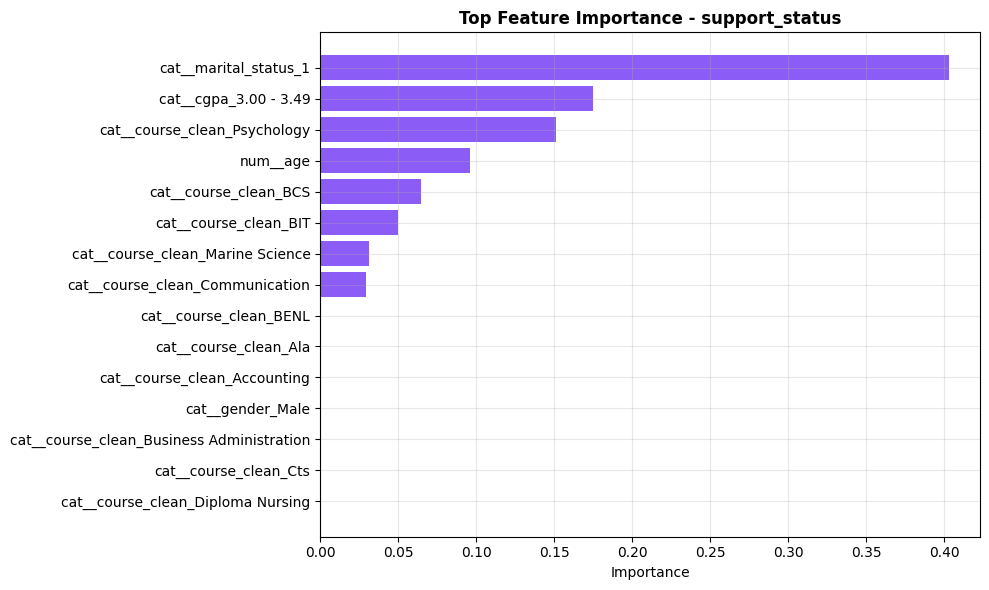

Model terbaik untuk **priority_segment** tidak memiliki `feature_importances_`. Jika membutuhkan interpretasi fitur, gunakan Random Forest atau Decision Tree sebagai model final.

In [13]:
def show_feature_importance(trained_pipeline, target_name):
    model = trained_pipeline.named_steps["model"]
    pre = trained_pipeline.named_steps["preprocessor"]

    try:
        feature_names = pre.get_feature_names_out()
    except Exception:
        feature_names = None

    if hasattr(model, "feature_importances_") and feature_names is not None:
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False).head(15)

        display(Markdown(f"### Feature Importance: {target_name}"))
        display(importance_df)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#8B5CF6")
        ax.set_title(f"Top Feature Importance - {target_name}")
        ax.set_xlabel("Importance")
        plt.tight_layout()
        plt.savefig(viz_dir / f"feature_importance_{target_name}.png", dpi=220, bbox_inches="tight")
        plt.show()

        importance_df.to_csv(table_dir / f"feature_importance_{target_name}.csv", index=False)
    else:
        display(Markdown(
            f"Model terbaik untuk **{target_name}** tidak memiliki `feature_importances_`. "
            "Jika membutuhkan interpretasi fitur, gunakan Random Forest atau Decision Tree sebagai model final."
        ))

show_feature_importance(best_support_model, "support_status")
show_feature_importance(best_priority_model, "priority_segment")

## 13. Export Hasil Prediksi

Bagian ini menyimpan:

- dataset berlabel,
- dataset dengan hasil prediksi,
- tabel perbandingan model,
- visualisasi evaluasi.

In [14]:
labeled_output = model_output_dir / "student_mental_health_labeled.csv"
prediction_output = model_output_dir / "student_mental_health_predictions.csv"

df.to_csv(labeled_output, index=False)
df_pred.to_csv(prediction_output, index=False)

print("Output tersimpan:")
print("-", labeled_output)
print("-", prediction_output)
print("-", table_dir)
print("-", viz_dir)

print("\nPreview hasil prediksi:")
display(df_pred.head())

Output tersimpan:
- c:\Users\MSI SWORD 16\Kuliah\Lomba\TEKRA\prediction_pipeline_outputs\predictions\student_mental_health_labeled.csv
- c:\Users\MSI SWORD 16\Kuliah\Lomba\TEKRA\prediction_pipeline_outputs\predictions\student_mental_health_predictions.csv
- c:\Users\MSI SWORD 16\Kuliah\Lomba\TEKRA\prediction_pipeline_outputs\tables
- c:\Users\MSI SWORD 16\Kuliah\Lomba\TEKRA\prediction_pipeline_outputs\visualizations

Preview hasil prediksi:


,student_id,timestamp,gender,age,course,course_clean,year_study,cgpa,marital_status,depression,...,priority_segment,predicted_support_status,predicted_priority_segment,proba_support_Reached Support,proba_support_Silent Struggle,proba_support_Stable / No Reported Indicator,proba_priority_High Concern,proba_priority_Low Concern,proba_priority_Stable,proba_priority_Supported
0,S001,8/7/2020 12:02,Female,18.0,Engineering,Engineering,Year 1,3.00 - 3.49,0,1,...,High Concern,Stable / No Reported Indicator,High Concern,0.0,0.3978,0.6022,0.3998,0.2458,0.3320,0.0223
1,S002,8/7/2020 12:04,Male,21.0,Islamic education,Islamic Education,Year 2,3.00 - 3.49,0,0,...,Low Concern,Stable / No Reported Indicator,Low Concern,0.0,0.3978,0.6022,0.1322,0.4981,0.3649,0.0048
2,S003,8/7/2020 12:05,Male,19.0,BIT,BIT,Year 1,3.00 - 3.49,0,1,...,High Concern,Silent Struggle,High Concern,0.0,0.8170,0.1830,0.5269,0.2681,0.1793,0.0257
3,S004,8/7/2020 12:06,Female,22.0,Laws,Laws,Year 3,3.00 - 3.49,1,1,...,Low Concern,Silent Struggle,Low Concern,0.0,1.0000,0.0000,0.3869,0.4547,0.0492,0.1091
4,S005,8/7/2020 12:13,Male,23.0,Mathemathics,Mathemathics,Year 4,3.00 - 3.49,0,0,...,Stable,Stable / No Reported Indicator,Stable,0.0,0.3978,0.6022,0.1066,0.1297,0.7610,0.0028


## 14. Catatan Evaluasi

Karena dataset hanya berisi 101 responden dan beberapa kelas memiliki jumlah data kecil, performa model perlu dibaca secara hati-hati.

Hal yang perlu diperhatikan:

1. Model ini belum layak digunakan sebagai sistem keputusan otomatis.
2. Label bersifat segmentasi analitik, bukan diagnosis medis.
3. Dataset perlu diperbesar sebelum model benar-benar diimplementasikan.
4. Model sebaiknya digunakan sebagai pendukung dashboard dan insight, bukan sebagai penentu tunggal kondisi mahasiswa.
5. Untuk implementasi Smart Campus nyata, perlu validasi bersama ahli psikologi, unit konseling, dan pengelola data kampus.